In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from src.config import (DATA_PATHS, 
                        BIZ,
                        MC_LIGHT,
                        PLT_PARAMS)
from src.data import (load_data, 
                      split_card_data, 
                      split_transactions_by_cards, 
                      fit_transform_scale_features, 
                      transform_scale_features,
                      combine_business_consumer_sets,
                      make_xy)
from src.features import (date_span_days, 
                          build_all_mcc_similarity_features,
                          make_card_features_final)
from src.modeling import (get_models, 
                          get_model_grids, 
                          grid_search_with_constraints, 
                          plot_gridsearch_results)

from matplotlib.colors import LinearSegmentedColormap as _LSC
plt.rcParams.update(PLT_PARAMS)
_CM_CMAP = _LSC.from_list('mc_cm', [MC_LIGHT, BIZ])

# Data Loading & Pre-Processing

In [3]:
business, consumer, merchants = load_data(DATA_PATHS)

In [4]:
total_days = date_span_days(pd.concat([business, consumer]))

## Feature Construction

In [5]:
bus_features = make_card_features_final(business, 1, total_days)
consumer_features = make_card_features_final(consumer, 0, total_days)

In [6]:
card_splits = split_card_data(bus_features, consumer_features)

In [7]:
trans_splits = split_transactions_by_cards(business, consumer, card_splits)

(business_mcc_features_train, 
 consumer_mcc_features_train, 
 business_profile, 
 consumer_profile) = build_all_mcc_similarity_features(trans_splits["business"]["train"],
                                                               trans_splits["consumer"]["train"])

(business_mcc_features_val, 
 consumer_mcc_features_val,
 _, _) = build_all_mcc_similarity_features(trans_splits["business"]["val"],
                                                   trans_splits["consumer"]["val"],
                                                   business_profile,
                                                   consumer_profile)

(business_mcc_features_test, 
 consumer_mcc_features_test,
 _, _) = build_all_mcc_similarity_features(trans_splits["business"]["test"],
                                                   trans_splits["consumer"]["test"],
                                                   business_profile,
                                                   consumer_profile)

In [8]:
business_mcc_features = pd.concat([
    business_mcc_features_train, 
    business_mcc_features_val, 
    business_mcc_features_test
])

consumer_mcc_features = pd.concat([
    consumer_mcc_features_train, 
    consumer_mcc_features_val, 
    consumer_mcc_features_test
])

In [9]:
business_mcc_features.info()

<class 'pandas.DataFrame'>
Index: 25000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   card_number                  25000 non-null  str    
 1   mcc_business_similarity_gap  25000 non-null  float64
 2   mcc_avg_distance             25000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 1.1 MB


In [10]:
bus_features = bus_features.merge(
    business_mcc_features,
    on = "card_number", 
    how = "left"
)

consumer_features = consumer_features.merge(
    consumer_mcc_features,
    on = "card_number", 
    how = "left"
)

In [11]:
df_splits = split_card_data(bus_features, consumer_features, card_splits = card_splits)

In [12]:
combined_splits = combine_business_consumer_sets(df_splits["business"], df_splits["consumer"])

In [13]:
X, y = make_xy(combined_splits, target_col = "type")

In [14]:
for i in X:
    X[i].drop("card_number", axis = 1, inplace = True)

X["train"]

,online_share,recurring_ratio,repeated_amount_ratio,recurring_it_services_turnover_ratio,recurring_digital_turnover_ratio,share_merchant_country_Kazakhstan,share_merchant_country_US,share_merchant_country_Ireland,active_days_ratio,log_turnover_per_active_day,log_tx_per_active_day,mcc_business_similarity_gap,mcc_avg_distance
0,0.865169,0.067416,0.056180,0.158686,0.269754,0.505091,0.266643,0.000000,0.576923,11.428673,0.991487,0.021479,0.572035
1,0.891892,0.040541,0.033784,0.160647,0.160647,0.715180,0.275281,0.000000,0.494505,11.888500,0.972461,0.096675,0.654736
2,0.925000,0.150000,0.125000,0.290570,0.426691,0.512817,0.316392,0.144744,0.439560,12.233194,0.916291,0.172482,0.438594
3,0.870130,0.038961,0.032468,0.118540,0.118540,0.768027,0.137362,0.000000,0.510989,12.227733,0.976789,0.029696,0.383201
4,0.781818,0.163636,0.136364,0.169093,0.227021,0.610902,0.180040,0.000000,0.417582,12.144697,0.895013,0.099216,0.349801
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62995,0.542986,0.054299,0.045249,0.003050,0.025715,0.401011,0.059943,0.539046,0.681319,12.131302,1.023263,0.231059,0.493682
62996,0.607477,0.000000,0.000000,0.000000,0.000000,0.516619,0.041039,0.000000,0.412088,11.675676,0.886519,-0.174019,0.459430
62997,0.525424,0.101695,0.084746,0.000000,0.009808,0.743788,0.021895,0.000000,0.269231,11.138515,0.790311,-0.056356,0.342970
62998,0.455446,0.059406,0.049505,0.000000,0.099268,0.163838,0.002235,0.150890,0.357143,11.030232,0.937601,-0.201376,0.313016


In [15]:
X_train = X["train"]
X_val = X["val"]
X_test = X["test"]

y_train = y["train"]
y_val = y["val"]
y_test = y["test"]

## Scaling

In [16]:
features_to_scale = [
    "log_tx_per_active_day",
    "log_turnover_per_active_day"
]

In [17]:
X_train, scaler = fit_transform_scale_features(X_train, features_to_scale)
X_val = transform_scale_features(X_val, features_to_scale, scaler)
X_test = transform_scale_features(X_test, features_to_scale, scaler)

# Modeling

In [18]:
models = get_models()

In [19]:
grids = get_model_grids()

## Logistic Regression

In [20]:
logreg = models['logistic_regression']
logreg_grid = grids['logistic_regression']

logreg_results = grid_search_with_constraints(logreg, logreg_grid, X_train, y_train, X_val, y_val)

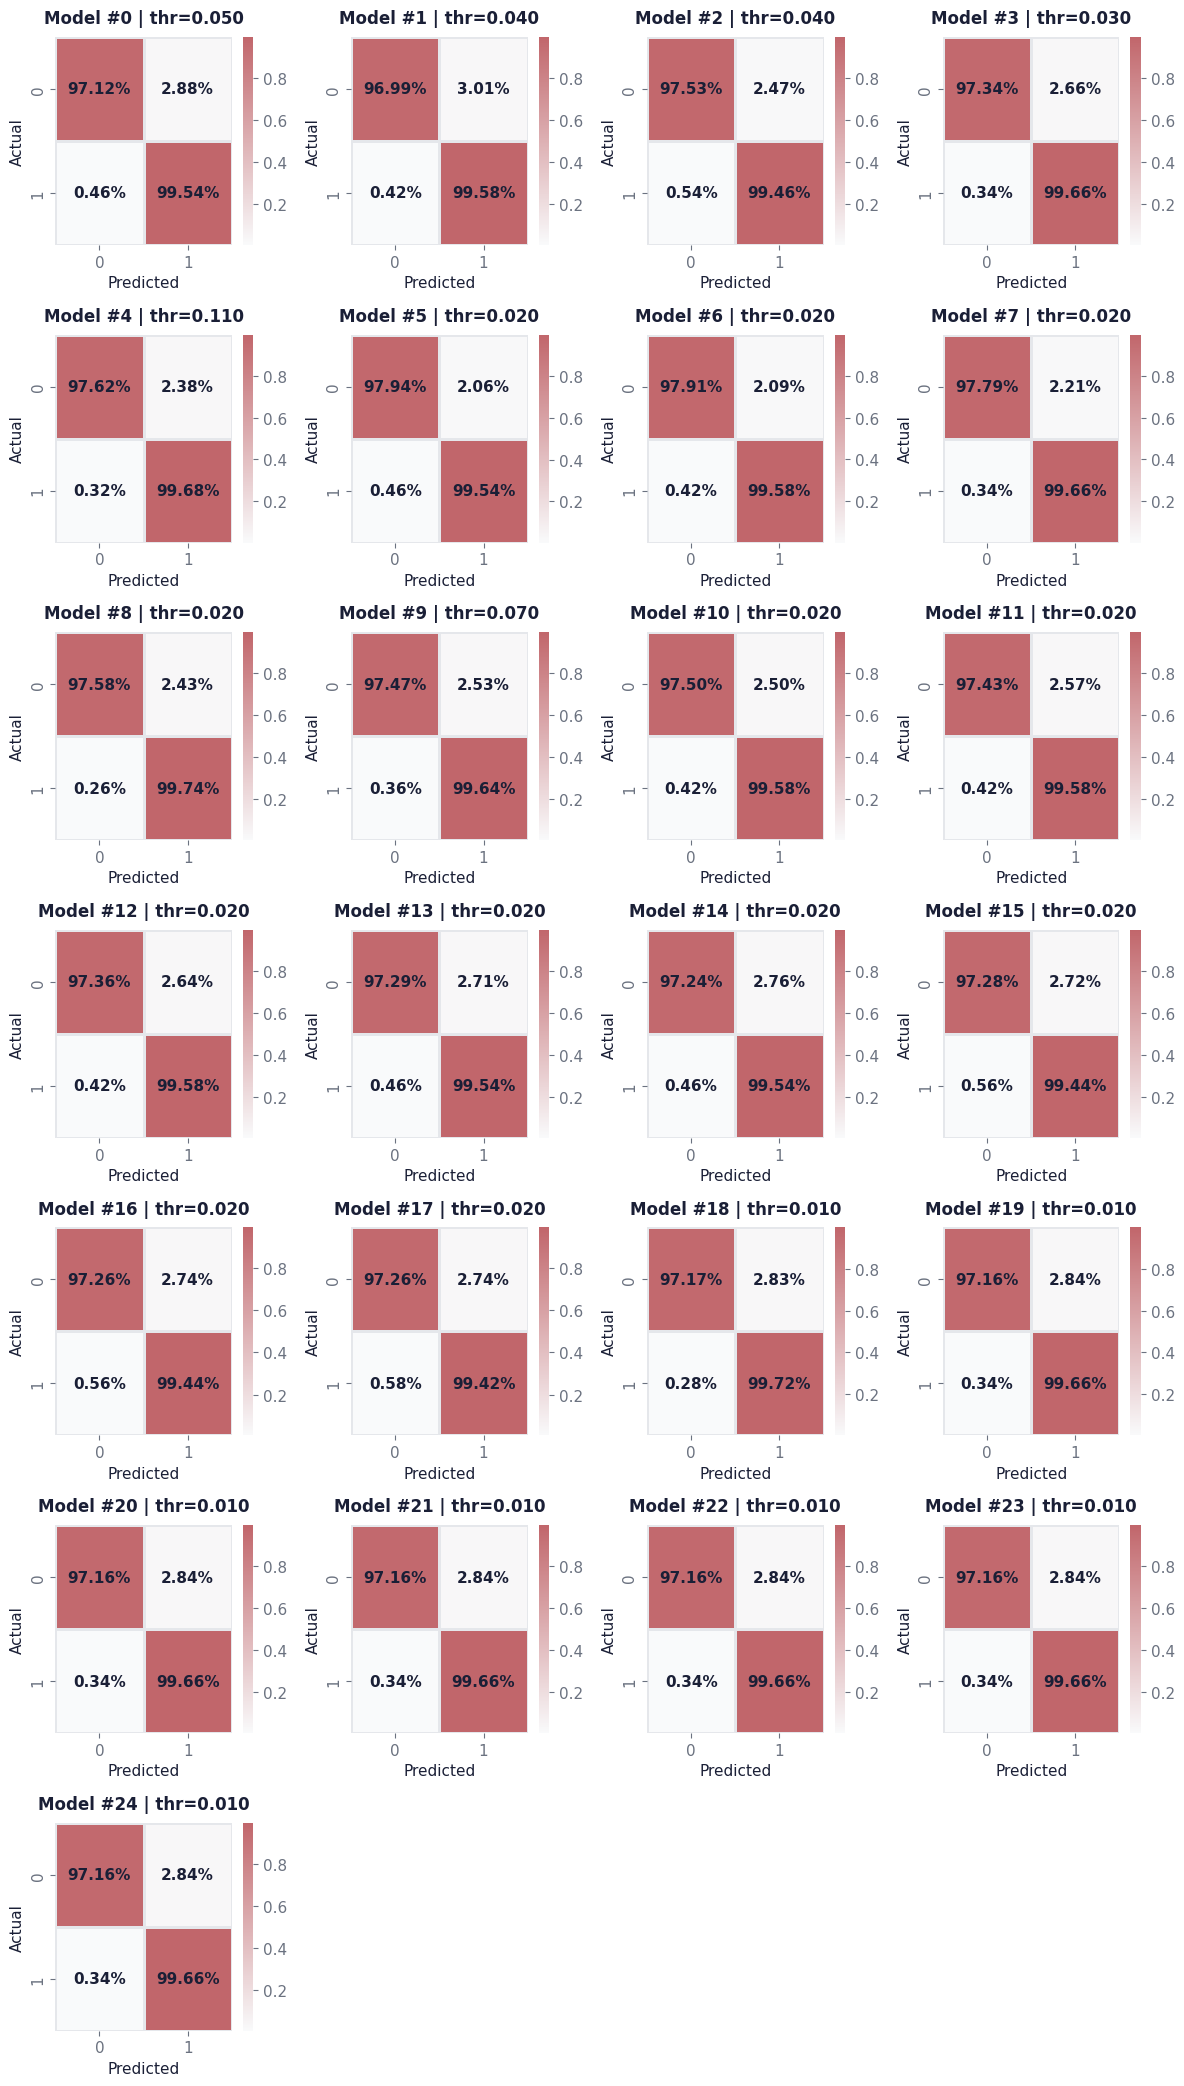

In [21]:
plot_gridsearch_results(logreg_results, X_test, y_test)

In [22]:
logreg = logreg_results[8]["model"]

## KNN

In [23]:
knn = models['knn']
knn_grid = {
            "n_neighbors": [15, 25, 35, 50, 75, 100],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }

knn_results = grid_search_with_constraints(knn, knn_grid, X_train, y_train, X_val, y_val)

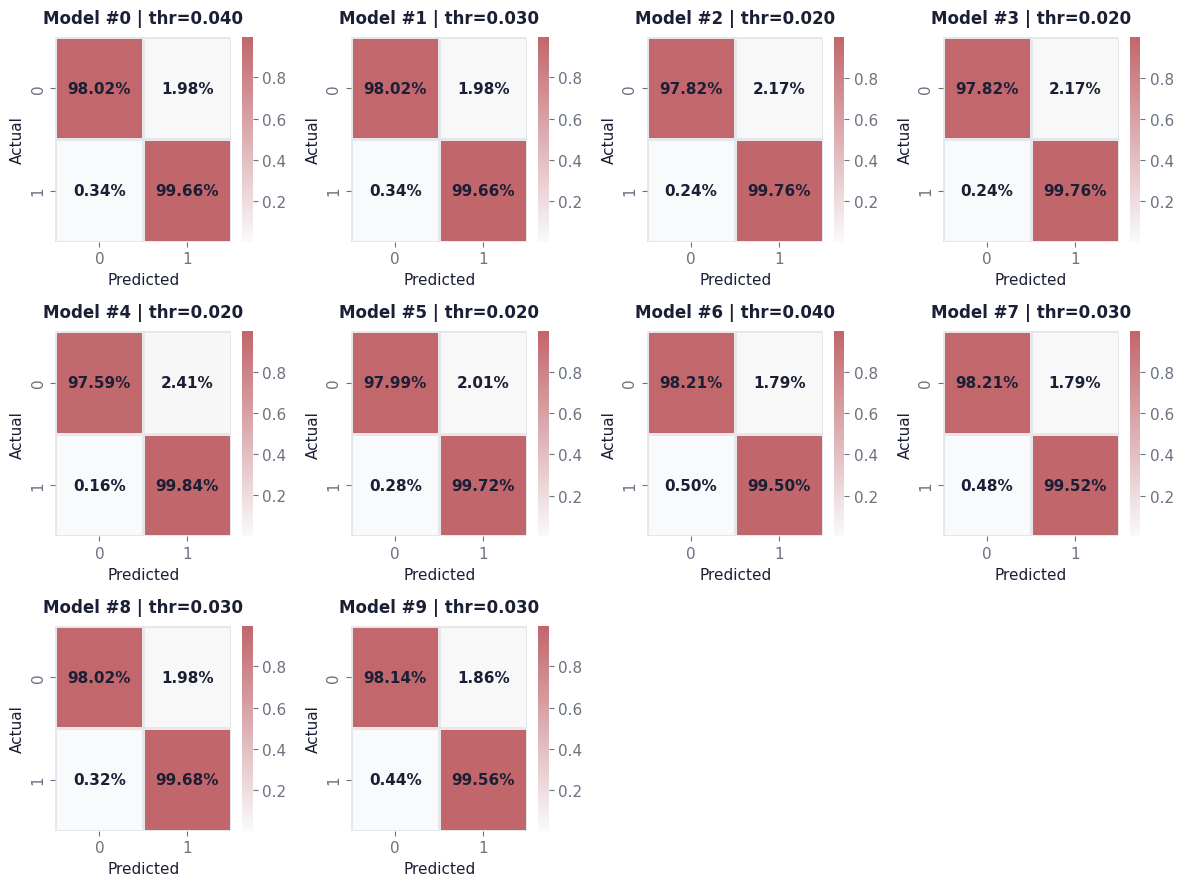

In [24]:
plot_gridsearch_results(knn_results, X_test, y_test)

In [25]:
knn = knn_results[4]["model"]

## SVM

In [26]:
svm = models['svm']
svm_grid = grids['svm']

svm_results = grid_search_with_constraints(svm, svm_grid, X_train, y_train, X_val, y_val)

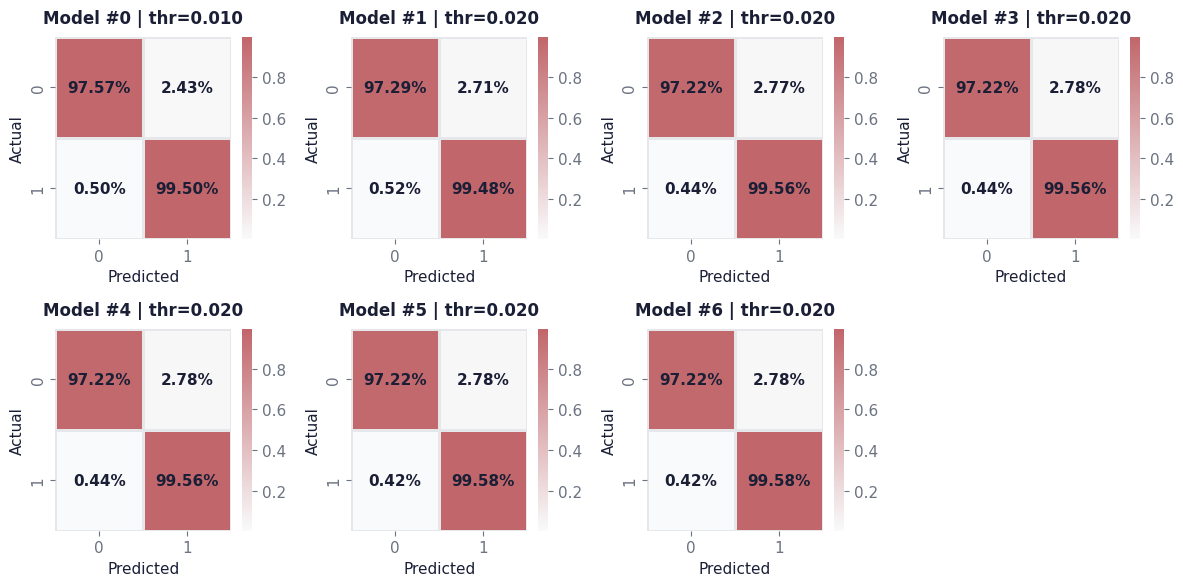

In [27]:
plot_gridsearch_results(svm_results, X_test, y_test)

In [28]:
svm = svm_results[5]["model"]

## Random Forest

In [29]:
rf = models['random_forest']
rf_grid = grids['random_forest']

rf_results = grid_search_with_constraints(rf, rf_grid, X_train, y_train, X_val, y_val)

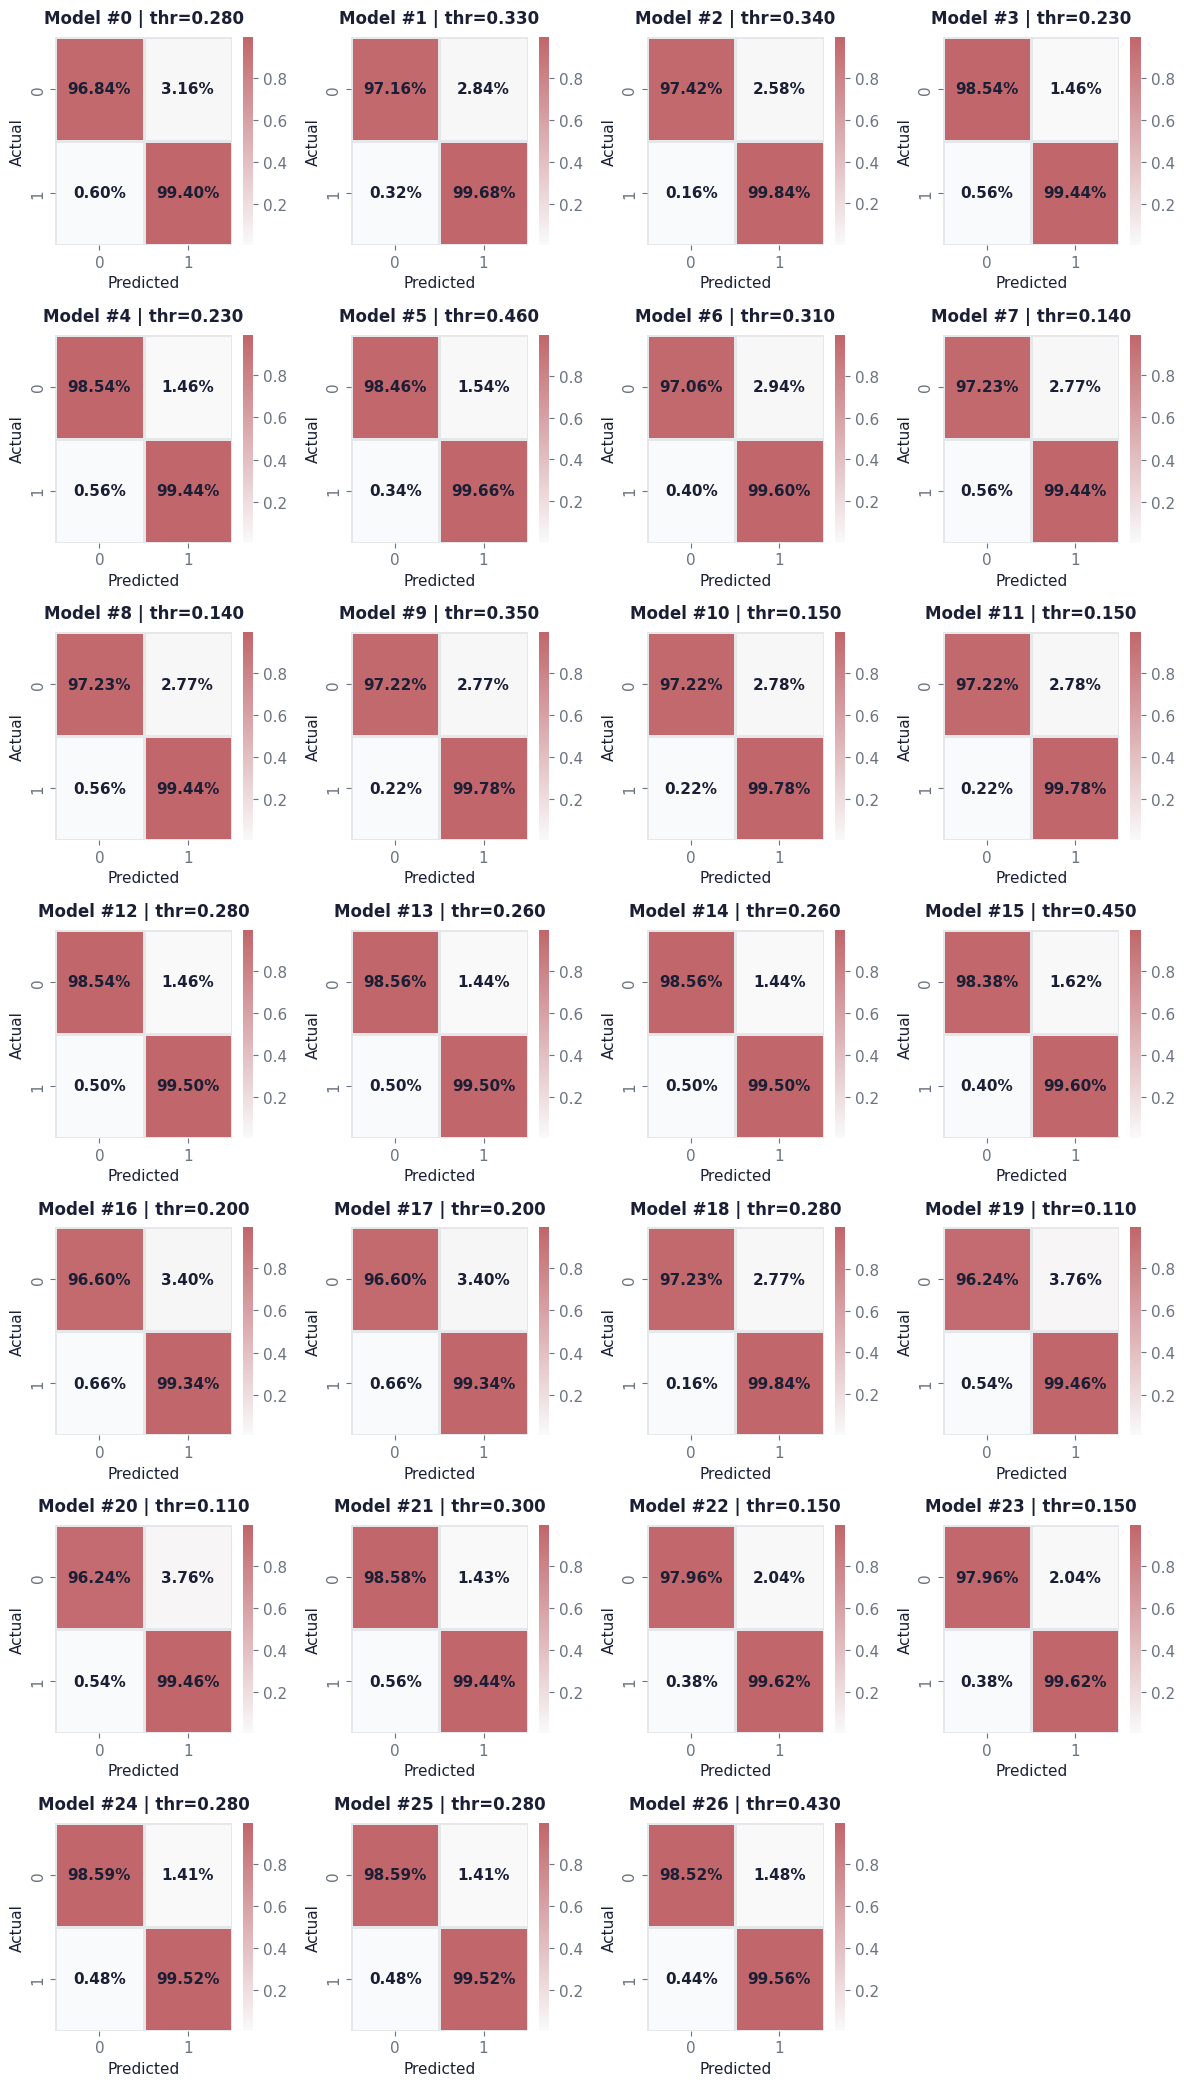

In [30]:
plot_gridsearch_results(rf_results, X_test, y_test)

In [31]:
rf = rf_results[18]["model"]

## XGBoost

In [32]:
xgboost = models['xgboost']
xgboost_grid = grids['xgboost']

xgboost_results = grid_search_with_constraints(xgboost, xgboost_grid, X_train, y_train, X_val, y_val)

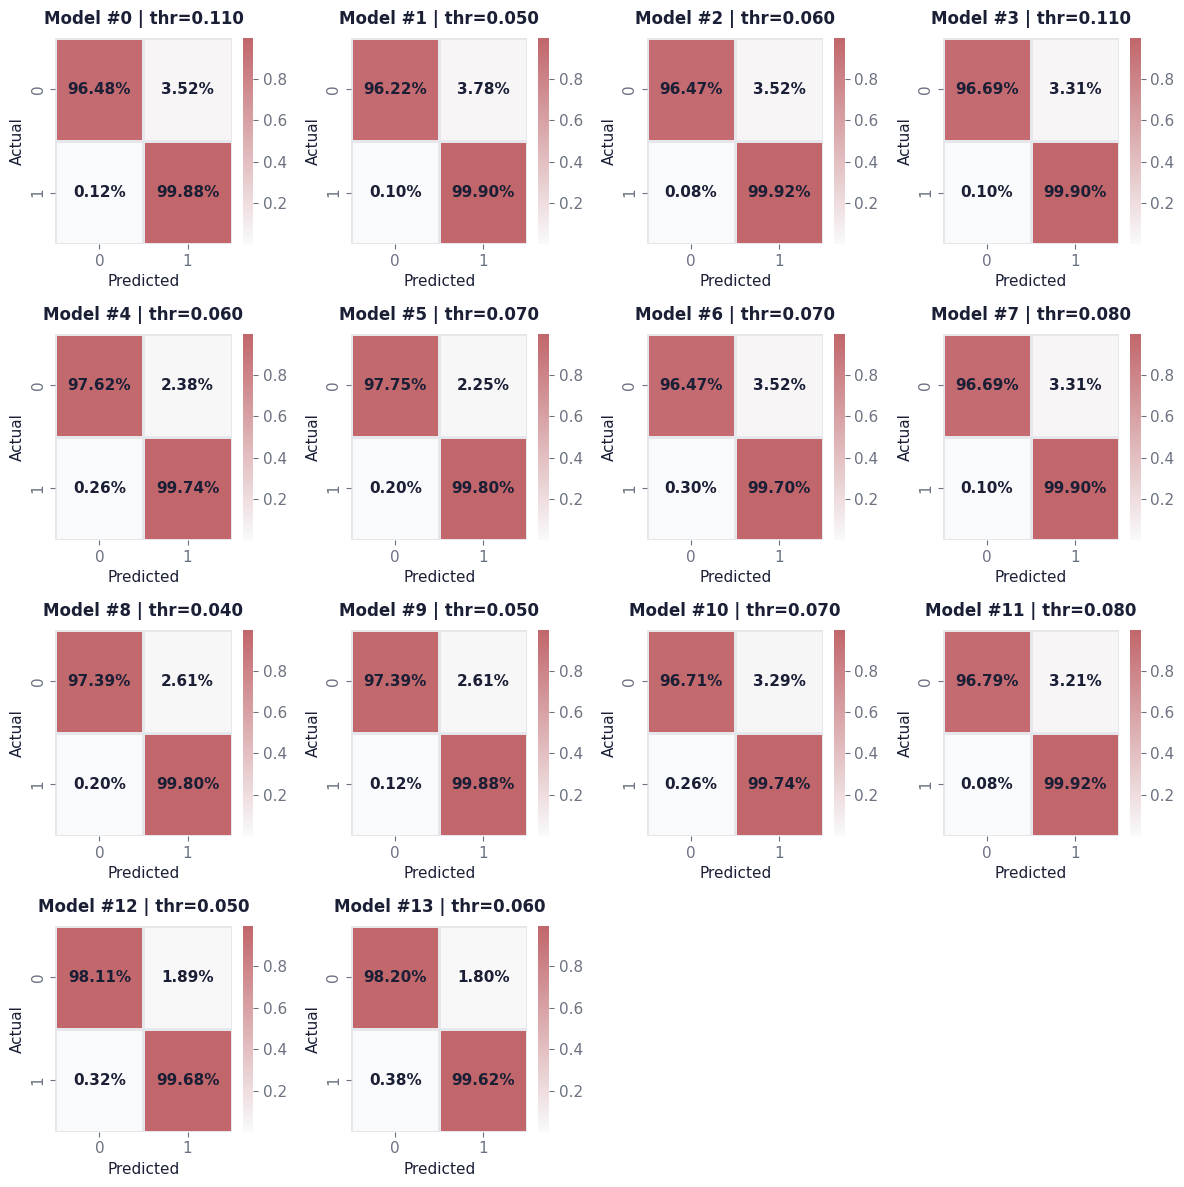

In [33]:
plot_gridsearch_results(xgboost_results, X_test, y_test)

In [34]:
xgboost = xgboost_results[11]["model"]

# Model Export

In [35]:
pickle.dump(logreg, open("../models/logistic_regression.pkl", "wb"))
pickle.dump(knn, open("../models/knn.pkl", "wb"))
pickle.dump(svm, open("../models/svm.pkl", "wb"))
pickle.dump(rf, open("../models/random_forest.pkl", "wb"))
pickle.dump(xgboost, open("../models/xgboost.pkl", "wb"))